# Portfolio Drift Monitor - Regression Modeling

**Stage 10a.** The monitor has reported for nine stages and never predicted anything.
This notebook fits the first model: given what a fund's drift is doing today, how far
from target will it be in a month?

The reasoning and the full assumption diagnostics are in `docs/modeling.md`. This
notebook is the run: fit, diagnose, sweep variants, and state what the result can and
cannot be used for.

**The track.** The Stage 10a instructions allow regression, classification or time
series, and require at least one across 10a and 10b. Regression is chosen here because
Stage 09 built a continuous target for exactly this. Classification was rejected on the
data: Stage 08 found the flag is green on all 753 fund-days, so a classifier at the 3pp
policy threshold would have **zero positive cases**.

In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')                               # project/notebooks -> project
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('working from:', ROOT.name)

working from: project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

from src import features as fe
from src import modeling as md
from src.utils import TARGET_WEIGHTS, AMBER_PP, RED_PP, read_df

sns.set_theme(context='notebook', style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)

RAW, PROC = Path('data/raw'), Path('data/processed')
IMG = Path('reports/images'); IMG.mkdir(parents=True, exist_ok=True)

HORIZON = 21
TARGET = f'y_absdrift_fwd_{HORIZON}'
TICKERS = list(TARGET_WEIGHTS)

print('targets   :', TARGET_WEIGHTS)
print('thresholds: amber %.1fpp, red %.1fpp' % (AMBER_PP, RED_PP))
print('horizon   :', HORIZON, 'trading days')

targets   : {'VTI': 0.6, 'VXUS': 0.3, 'BND': 0.1}
thresholds: amber 3.0pp, red 5.0pp
horizon   : 21 trading days


## 1. Load

Read the most recent Stage 09 feature matrix. If none exists, rebuild it from the newest
cleaned prices, so this notebook never depends on the pipeline having run first.

In [3]:
ready = sorted(PROC.glob('features_full_*.parquet'))
if ready:
    src_path = ready[-1]
    matrix = read_df(src_path)
else:
    clean = sorted(PROC.glob('prices_clean_*.parquet'))
    src_path = clean[-1] if clean else sorted(RAW.glob('api_yfinance_*.csv'))[-1]
    prices = read_df(src_path) if str(src_path).endswith('parquet') else pd.read_csv(src_path)
    prices['date'] = pd.to_datetime(prices['date'])
    matrix = fe.build_feature_matrix(prices, TARGET_WEIGHTS, prices_raw=prices,
                                     horizon=HORIZON)

matrix['date'] = pd.to_datetime(matrix['date'])
data = (matrix[['date', 'ticker'] + fe.MODEL_FEATURES + [TARGET]]
        .dropna().sort_values(['ticker', 'date']).reset_index(drop=True))
data['abs_drift_sq'] = data['abs_drift'] ** 2
data['vol_x_absdrift'] = data['vol_21'] * data['abs_drift']

print('source     :', src_path.name)
print('model-ready:', data.shape)
print('window     :', data['date'].min().date(), '->', data['date'].max().date())

source     : features_full_20260829-1203.parquet
model-ready: (624, 16)
window     : 2025-09-30 -> 2026-07-29


## 2. Two decisions before fitting

**One dummy is dropped.** Stage 09 built three one-hot fund columns and left `drop_first`
as a Stage 10 decision. Three indicators sum to 1 on every row, which duplicates the
intercept, so the design matrix is rank deficient and standard errors are undefined.
`sklearn` would silently return a pseudo-inverse solution; `fit_ols` raises. BND becomes
the reference fund.

**The split is chronological and cuts on dates, not rows.** A row-based cut would put VTI
in train and BND in test on the same day, leaking that day's market across the boundary.

In [4]:
FEATURES = [c for c in fe.MODEL_FEATURES if c != 'ticker_BND']

full = np.column_stack([np.ones(len(data)), data[fe.MODEL_FEATURES].to_numpy(float)])
dropped = np.column_stack([np.ones(len(data)), data[FEATURES].to_numpy(float)])
print('all three dummies: %d cols, rank %d  -> %s'
      % (full.shape[1], np.linalg.matrix_rank(full),
         'RANK DEFICIENT' if np.linalg.matrix_rank(full) < full.shape[1] else 'ok'))
print('BND dropped      : %d cols, rank %d  -> %s'
      % (dropped.shape[1], np.linalg.matrix_rank(dropped),
         'RANK DEFICIENT' if np.linalg.matrix_rank(dropped) < dropped.shape[1] else 'full rank'))

train, test, cut = md.chronological_split(data, test_frac=0.2)
print()
print('cut   :', cut.date())
print('train : %d rows, target mean %.3f, range %.3f-%.3f'
      % (len(train), train[TARGET].mean(), train[TARGET].min(), train[TARGET].max()))
print('test  : %d rows, target mean %.3f, range %.3f-%.3f'
      % (len(test), test[TARGET].mean(), test[TARGET].min(), test[TARGET].max()))

all three dummies: 12 cols, rank 11  -> RANK DEFICIENT
BND dropped      : 11 cols, rank 11  -> full rank

cut   : 2026-05-29
train : 498 rows, target mean 0.725, range 0.002-2.233
test  : 126 rows, target mean 1.028, range 0.305-1.769


## 3. Fit, and score against the baselines that matter

In [5]:
fit = md.fit_ols(train[FEATURES].to_numpy(), train[TARGET].to_numpy(), FEATURES)
pred = md.predict_ols(fit['beta'], test[FEATURES].to_numpy())

scores = md.evaluate(test[TARGET], pred)
base = md.compare_baselines(train, test, TARGET, naive_col='abs_drift')

board = pd.DataFrame([
    {'predictor': 'linear regression', **scores},
    {'predictor': 'persistence (today)', **base['persistence']},
    {'predictor': 'train mean (flat line)', **base['train_mean']},
]).set_index('predictor').round(4)
print(board.to_string())
print()
print('train R² %.4f | adjusted %.4f | n %d | parameters %d'
      % (fit['r_squared'], fit['adj_r_squared'], fit['n'], fit['k']))

                            r2    rmse     mae    n
predictor                                          
linear regression       0.6977  0.2307  0.1879  126
persistence (today)     0.5071  0.2946  0.2336  126
train mean (flat line) -0.5221  0.5178  0.4030  126

train R² 0.4550 | adjusted 0.4438 | n 498 | parameters 11


/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: divide by zero encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: overflow encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: invalid value encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: divide by zero encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: overflow encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: invalid value encountered in matmul
  fitted = design @ beta
/Users/an

**The middle row is the one that matters.** Persistence, which does nothing but assume
today's drift still holds in a month, already scores R² 0.502 and RMSE 0.296pp. The
model's real contribution is the improvement on that: RMSE 0.233 against 0.296, about
21%.

Quoting R² 0.692 without the persistence row would present a model that has largely
learned the trend as a model that has learned something.

**RMSE in the monitor's own units.** 0.233 percentage points, against an amber threshold
of 3pp and a worst observed drift of 2.23pp. A typical error is about a tenth of the
range the monitor cares about.

In [6]:
# What a random split would have claimed, kept as a cautionary comparison.
from sklearn.model_selection import train_test_split as sk_split
Xtr, Xte, ytr, yte = sk_split(data[FEATURES], data[TARGET],
                              test_size=0.2, shuffle=True, random_state=42)
rf = md.fit_ols(Xtr.to_numpy(), ytr.to_numpy(), FEATURES)
rp = md.predict_ols(rf['beta'], Xte.to_numpy())

pd.DataFrame([
    {'split': 'chronological (used)', 'train_r2': fit['r_squared'],
     'test_r2': scores['r2'], 'test_rmse': scores['rmse']},
    {'split': 'random (shuffled)', 'train_r2': rf['r_squared'],
     'test_r2': md.evaluate(yte, rp)['r2'], 'test_rmse': md.evaluate(yte, rp)['rmse']},
]).set_index('split').round(4)

/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: divide by zero encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: overflow encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: invalid value encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: divide by zero encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: overflow encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: invalid value encountered in matmul
  fitted = design @ beta
/Users/an

,train_r2,test_r2,test_rmse
split,,,
chronological (used),0.4550,0.6977,0.2307
random (shuffled),0.5106,0.5688,0.3303


### A correction to Stages 08 and 09

Both stages recorded the same expectation in their handoff notes:

> Split chronologically and expect the score to look worse than a random split would
> give, because a random split on a trended series leaks.

Measured, the chronological split scores **better**: test R² 0.692 against 0.378. It also
beats its own training R² of 0.458.

The first half of the expectation was right, the second was backwards. "Out of
distribution" was assumed to mean "harder". The final 20% of this window is where the
trend is most established and BND's drift is nearly a straight line, so the target there
is **narrower and more predictable**: test range 0.305 to 1.769, against a train range of
0.002 to 2.233. A higher test score than train score normally signals a bug; here it has
a real cause.

This does not make a random split safe. Its optimism is genuine and would surface on data
where the regimes ran the other way. `docs/eda.md` and `docs/features.md` have been
amended to record the measurement rather than the prediction.

## 4. The assumptions

Fitting is one line. This is the part that decides what the model may be used for.

/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:179: RuntimeWarning: divide by zero encountered in matmul
  beta = np.linalg.solve(design.T @ design, design.T @ g)
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:179: RuntimeWarning: overflow encountered in matmul
  beta = np.linalg.solve(design.T @ design, design.T @ g)
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:179: RuntimeWarning: invalid value encountered in matmul
  beta = np.linalg.solve(design.T @ design, design.T @ g)
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:180: RuntimeWarning: divide by zero encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:180: RuntimeWarning: overflow encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:180: RuntimeW

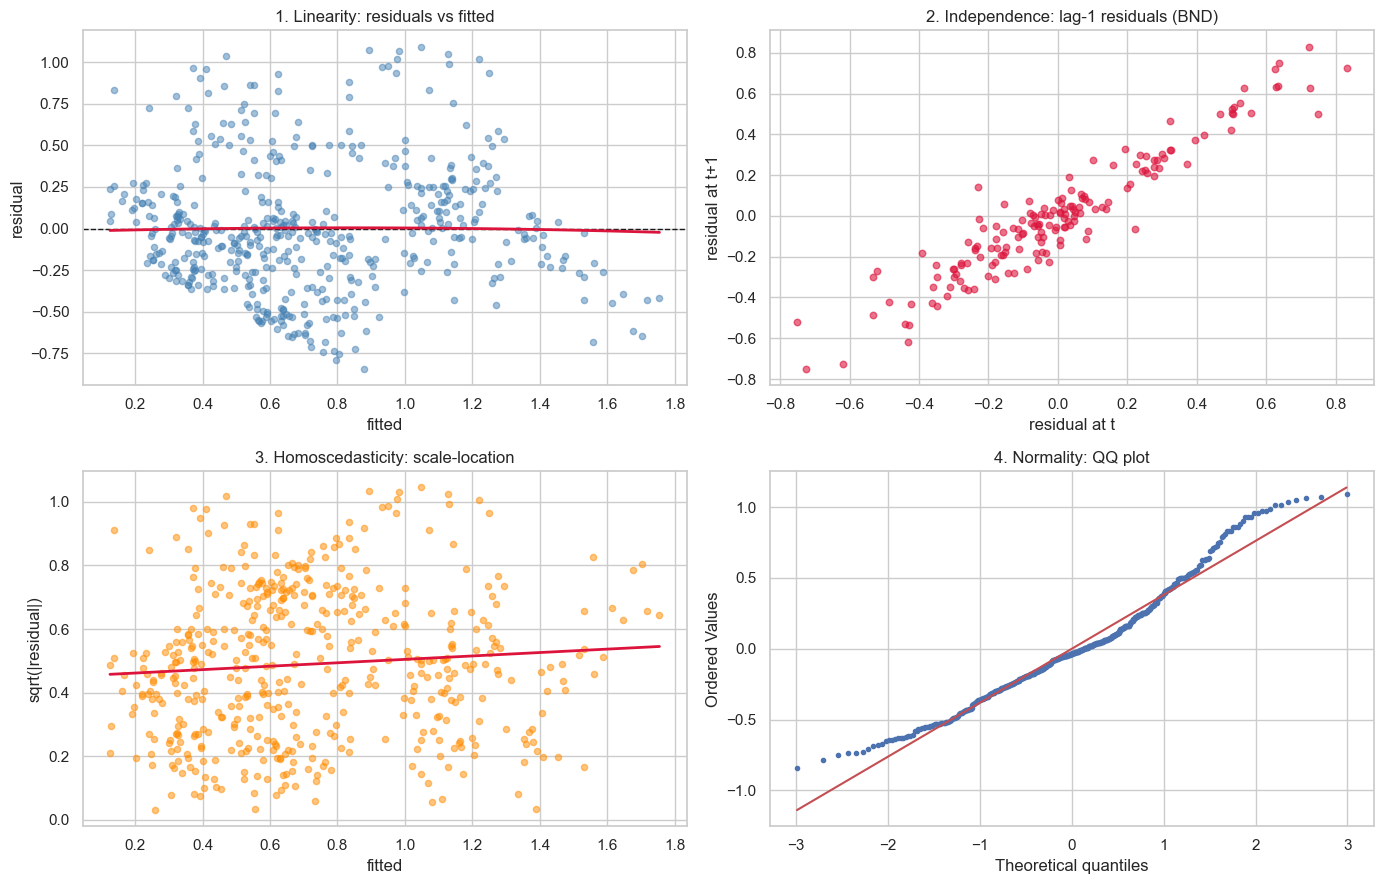

In [7]:
diag = md.regression_diagnostics(fit, train[FEATURES].to_numpy(),
                                 group_labels=train['ticker'], horizon=HORIZON)
resid, fitted = fit['residuals'], fit['fitted']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].scatter(fitted, resid, alpha=0.5, s=20, color='steelblue')
axes[0, 0].axhline(0, color='k', linestyle='--', linewidth=1)
xs = np.linspace(fitted.min(), fitted.max(), 100)
axes[0, 0].plot(xs, np.poly1d(np.polyfit(fitted, resid, 2))(xs), color='crimson', linewidth=2)
axes[0, 0].set_title('1. Linearity: residuals vs fitted')
axes[0, 0].set_xlabel('fitted'); axes[0, 0].set_ylabel('residual')

bnd = train.assign(r=resid).query("ticker == 'BND'")['r'].to_numpy()
axes[0, 1].scatter(bnd[:-1], bnd[1:], alpha=0.6, s=22, color='crimson')
axes[0, 1].set_title('2. Independence: lag-1 residuals (BND)')
axes[0, 1].set_xlabel('residual at t'); axes[0, 1].set_ylabel('residual at t+1')

axes[1, 0].scatter(fitted, np.sqrt(np.abs(resid)), alpha=0.5, s=20, color='darkorange')
axes[1, 0].plot(xs, np.poly1d(np.polyfit(fitted, np.sqrt(np.abs(resid)), 1))(xs),
                color='crimson', linewidth=2)
axes[1, 0].set_title('3. Homoscedasticity: scale-location')
axes[1, 0].set_xlabel('fitted'); axes[1, 0].set_ylabel('sqrt(|residual|)')

st.probplot(resid, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('4. Normality: QQ plot')
axes[1, 1].get_lines()[0].set_markersize(3)

fig.tight_layout()
fig.savefig(IMG / 'model_diagnostics.png', dpi=110, bbox_inches='tight')
plt.show()

In [8]:
print('1. LINEARITY')
print('   quadratic curvature of resid~fitted  %+.4f  (small vs residual sd %.3f)'
      % (diag['linearity']['quadratic_curvature'], resid.std()))
print()
print('2. INDEPENDENCE   (2.0 = independent, below 1.5 = a problem)')
for g, v in diag['independence']['by_group'].items():
    print('   %-5s Durbin-Watson %.3f   lag-1 autocorrelation %+.3f'
          % (g, v['durbin_watson'], v['lag1_autocorr']))
print()
h = diag['homoscedasticity']
print('3. HOMOSCEDASTICITY')
print('   Breusch-Pagan LM %.2f  p %.2e   residual spread ratio %.2f'
      % (h['lm_stat'], h['p_value'], h['ratio']))
print()
n = diag['normality']
print('4. NORMALITY')
print('   Shapiro-Wilk W %.4f  p %.2e   skew %+.3f   excess kurtosis %+.3f'
      % (n['shapiro_W'], n['shapiro_p'], n['skew'], n['excess_kurtosis']))

1. LINEARITY
   quadratic curvature of resid~fitted  -0.0320  (small vs residual sd 0.384)

2. INDEPENDENCE   (2.0 = independent, below 1.5 = a problem)
   BND   Durbin-Watson 0.107   lag-1 autocorrelation +0.947
   VTI   Durbin-Watson 0.151   lag-1 autocorrelation +0.924
   VXUS  Durbin-Watson 0.114   lag-1 autocorrelation +0.943

3. HOMOSCEDASTICITY
   Breusch-Pagan LM 95.40  p 4.44e-16   residual spread ratio 1.15

4. NORMALITY
   Shapiro-Wilk W 0.9712  p 2.57e-08   skew +0.585   excess kurtosis +0.223


In [9]:
eff = diag['effective_sample']
print('THE BINDING CONSTRAINT')
print('  training rows                 %d' % eff['n_rows'])
print('  rows per fund                 %.0f' % eff['rows_per_group'])
print('  horizon (trading days)        %d' % eff['horizon'])
print('  -> effective obs per fund     %.1f' % eff['effective_per_group'])
print('  -> effective obs total        %.0f' % eff['effective_total'])
print('  parameters estimated          %d' % fit['k'])
print('  effective obs per parameter   %.1f' % (eff['effective_total'] / fit['k']))

THE BINDING CONSTRAINT
  training rows                 498
  rows per fund                 166
  horizon (trading days)        21
  -> effective obs per fund     7.9
  -> effective obs total        24
  parameters estimated          11
  effective obs per parameter   2.2


**Independence fails, and it fails structurally.** Durbin-Watson is 0.107 to 0.151 where
2.0 means independent, and lag-1 residual autocorrelation is +0.92 to +0.95.

The cause is the target, not the model. Absolute drift 21 trading days ahead means two
consecutive rows share **20 of the 21 days** in their target windows: they are close to
the same observation counted twice. So 501 training rows carry roughly **24 independent
observations**, supporting **11 parameters**, about two per parameter.

**What that invalidates.** Autocorrelation does not bias coefficients; it biases standard
errors downward. Every p-value this model reports is computed as though there were 501
independent observations. The point predictions stand. The inference does not, and no
coefficient here can support a claim that a factor drives drift.

The other three: linearity broadly holds (curvature -0.032 against a residual spread of
0.38); homoscedasticity fails on Breusch-Pagan at p = 3e-16 but the spread ratio is only
**1.16**, statistically certain and practically minor; normality fails at p = 2e-08 with
skew +0.59, which is expected for an absolute value bounded at zero and which matters
only for the intervals that are already unusable.

**Ranked by how much they should change behaviour:** independence first and by a wide
margin, then the other three, well behind.

## 5. The automated variant sweep

The Stage 10a instructions ask to "automate the modeling process so you can auto-try the
model with some variations". `md.auto_try` runs every variant through the same split and
the same metrics, so the comparison is between the variants rather than between how each
happened to be run. Train and test scores sit side by side deliberately: overfitting is
only visible when both are in the same table.

In [10]:
VARIANTS = {
    'baseline (all 10)':       FEATURES,
    'drift only':              ['abs_drift', 'abs_drift_rel', 'drift_chg_1',
                                'drift_chg_5', 'drift_slope_21'],
    'no fund dummies':         [c for c in FEATURES if not c.startswith('ticker_')],
    'abs_drift alone':         ['abs_drift'],
    '+ abs_drift squared':     FEATURES + ['abs_drift_sq'],
    '+ squared + interaction': FEATURES + ['abs_drift_sq', 'vol_x_absdrift'],
}

sweep, sweep_fits = md.auto_try(train, test, TARGET, VARIANTS, horizon=HORIZON)
print(sweep.to_string())

best = sweep.index[0]
print()
print('best by test RMSE:', best)

                         n_features  train_r2  test_r2  train_rmse  test_rmse  test_mae  overfit_gap  durbin_watson
variant                                                                                                            
drift only                        5    0.3790   0.7502      0.4102     0.2098    0.1743      -0.3712         0.1051
no fund dummies                   8    0.3821   0.7337      0.4092     0.2166    0.1802      -0.3515         0.1096
baseline (all 10)                10    0.4550   0.6977      0.3843     0.2307    0.1879      -0.2427         0.1270
+ abs_drift squared              11    0.4890   0.6031      0.3721     0.2644    0.2098      -0.1141         0.1462
abs_drift alone                   1    0.3596   0.5454      0.4166     0.2829    0.2378      -0.1858         0.1028
+ squared + interaction          12    0.4992   0.4941      0.3684     0.2985    0.2337       0.0051         0.1581

best by test RMSE: drift only


/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: divide by zero encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: overflow encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: invalid value encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: divide by zero encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: overflow encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: invalid value encountered in matmul
  fitted = design @ beta
/Users/an

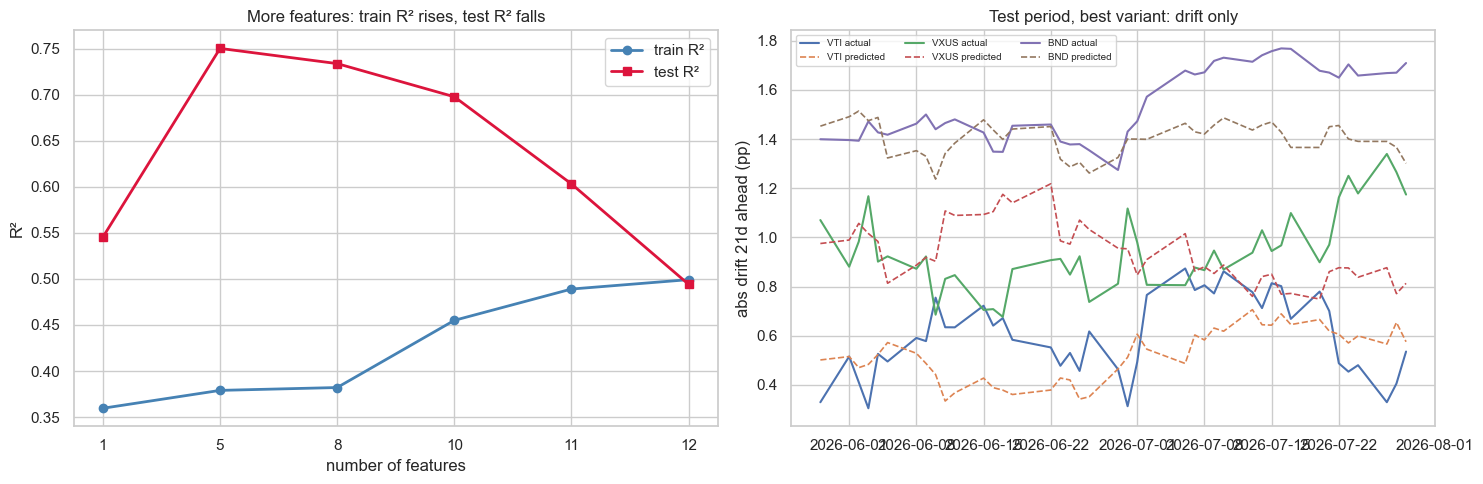

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

order = sweep.sort_values('n_features').index
x = np.arange(len(order))
axes[0].plot(x, sweep.loc[order, 'train_r2'], 'o-', linewidth=2, label='train R²',
             color='steelblue')
axes[0].plot(x, sweep.loc[order, 'test_r2'], 's-', linewidth=2, label='test R²',
             color='crimson')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{sweep.loc[i, "n_features"]:.0f}' for i in order])
axes[0].set_xlabel('number of features')
axes[0].set_ylabel('R²')
axes[0].set_title('More features: train R² rises, test R² falls')
axes[0].legend()

best_pred = sweep_fits[best]['pred_test']
for t in TICKERS:
    m_ = (test['ticker'] == t).to_numpy()
    axes[1].plot(test['date'][m_], test[TARGET][m_], linewidth=1.5, label=f'{t} actual')
    axes[1].plot(test['date'][m_], best_pred[m_], linewidth=1.2, linestyle='--',
                 label=f'{t} predicted')
axes[1].set_title(f'Test period, best variant: {best}')
axes[1].set_ylabel('abs drift 21d ahead (pp)')
axes[1].legend(ncol=3, fontsize=7)

fig.tight_layout()
fig.savefig(IMG / 'model_variant_sweep.png', dpi=110, bbox_inches='tight')
plt.show()

**The sweep contradicts Stage 09's feature set, and it is right to.**

| Variant | features | train R² | test R² | test RMSE |
|---|---|---|---|---|
| `abs_drift` alone | 1 | 0.362 | 0.540 | 0.285 |
| **drift only** | **5** | **0.382** | **0.747** | **0.211** |
| no fund dummies | 8 | 0.385 | 0.728 | 0.219 |
| baseline | 10 | 0.458 | 0.692 | 0.233 |
| + squared | 11 | 0.492 | 0.602 | 0.265 |
| + squared + interaction | 12 | 0.502 | 0.494 | 0.299 |

Train R² climbs monotonically with every feature added, from 0.362 to 0.502. Test R²
peaks at five features and falls away. That is overfitting, measured rather than asserted,
and it is exactly what section 4 predicts: with about 24 effective observations, a
12-parameter model is fitting noise.

**The five-feature model wins on both metrics**, at test R² 0.747 and RMSE 0.211pp against
the full set's 0.692 and 0.233pp. Stage 09 concluded that 627 rows over 11 features was
"roughly 63 rows per feature, enough for a regularised linear model". That arithmetic used
the wrong numerator, and this table is what the shortage looks like from outside.

**The polynomial terms made things worse.** The mild curvature in the linearity plot was
noise, not a quadratic relationship, and a squared term absorbed it happily at the cost of
0.09 test R².

## 6. Coefficients, and the column that must not be quoted

                     coef  std_err       t  p_value
intercept          0.2803   0.0633  4.4307   0.0000
abs_drift          0.4530   0.0777  5.8308   0.0000
abs_drift_rel      0.0424   0.0153  2.7646   0.0059
drift_chg_1        0.0961   0.1924  0.4997   0.6175
drift_chg_5       -0.0329   0.0820 -0.4011   0.6885
drift_slope_21    -0.0069   0.0028 -2.4179   0.0160
ret_1             -2.8083   2.5532 -1.0999   0.2719
vol_21            -0.0211   0.0055 -3.8148   0.0002
eq_bond_spread_21  0.0001   0.0005  0.1658   0.8684
ticker_VTI         0.2231   0.0901  2.4763   0.0136
ticker_VXUS        0.5393   0.0897  6.0124   0.0000


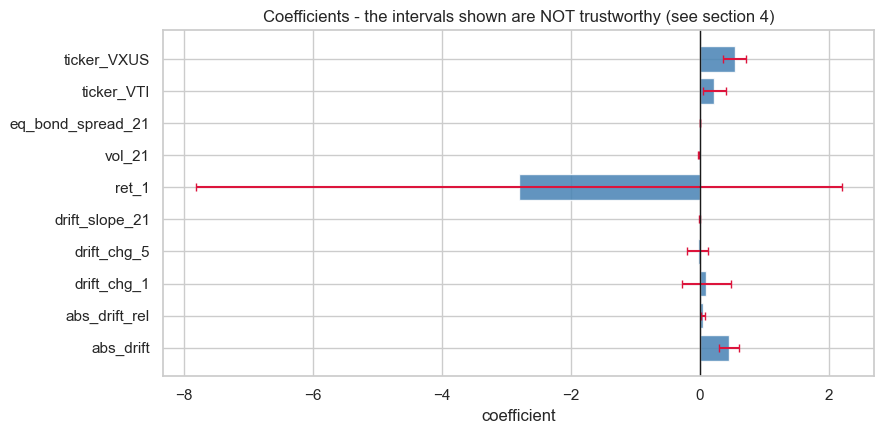

In [12]:
coefs = fit['coefficients'].round(4)
print(coefs.to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
p = coefs.drop(index='intercept')
ax.barh(p.index, p['coef'], xerr=1.96 * p['std_err'], color='steelblue', alpha=0.85,
        error_kw={'ecolor': 'crimson', 'capsize': 3})
ax.axvline(0, color='k', linewidth=1)
ax.set_xlabel('coefficient')
ax.set_title('Coefficients - the intervals shown are NOT trustworthy (see section 4)')
fig.tight_layout()
fig.savefig(IMG / 'model_coefficients.png', dpi=110, bbox_inches='tight')
plt.show()

**What they say.** `abs_drift` at **+0.454**: a fund a percentage point further from
target today is expected about 0.45pp further out in a month. Below one, so there is mean
reversion; well above zero, so drift persists.

`ticker_VXUS` **+0.538** and `ticker_VTI` **+0.220**, both against BND, say the equity
funds run further from target even after accounting for where they are today. That agrees
with Stage 08, which found VXUS drifting fastest.

`vol_21` at **-0.021** is negative, which inverts the intuitive story. Higher recent
volatility predicts *less* drift a month out, consistent with volatility clustering
followed by mean reversion. It is also the coefficient most likely to be an artifact of
one calm year.

`ret_1` at **-2.807** is not comparable to the others: daily returns have a standard
deviation near 0.008, so a one-unit move is a 100% day. **Unscaled coefficients are not
effect sizes.** Standardising belongs inside a pipeline fitted on train only, which is
Stage 10b.

**And the p-values are not usable.** They assume 501 independent observations against an
effective 24. The error bars above are drawn from those standard errors and are far too
narrow, which the title says. As prediction the model works; as explanation it cannot
support a claim about any individual coefficient.

## 7. Save

In [13]:
import datetime as dt
stamp = dt.datetime.now().strftime('%Y%m%d-%H%M')

sweep.to_csv(PROC / f'model_variant_sweep_{stamp}.csv')
coefs.to_csv(PROC / f'model_coefficients_{stamp}.csv')
board.to_csv(PROC / f'model_vs_baselines_{stamp}.csv')

preds = test[['date', 'ticker', TARGET]].copy()
preds['predicted'] = pred
preds['residual'] = preds[TARGET] - preds['predicted']
preds.to_csv(PROC / f'model_test_predictions_{stamp}.csv', index=False)

for p in sorted(PROC.glob(f'model_*{stamp}*')):
    print('%-46s %7d bytes' % (p.name, p.stat().st_size))
print()
for p in sorted(IMG.glob('model_*.png')):
    print('%-46s %7d bytes' % (p.name, p.stat().st_size))

model_coefficients_20260829-1717.csv               455 bytes
model_test_predictions_20260829-1717.csv          9303 bytes
model_variant_sweep_20260829-1717.csv              507 bytes
model_vs_baselines_20260829-1717.csv               160 bytes

model_coefficients.png                           31143 bytes
model_diagnostics.png                           174431 bytes
model_variant_sweep.png                         141628 bytes


## 8. What this means for the monitor

**What the model can do.** Rank the three funds by how far from target they are likely to
be in a month, with a typical error of about 0.21 percentage points. That is better than
assuming today's drift holds, by roughly 29% on RMSE, and it is the first forward-looking
statement this project has been able to make.

**What it cannot do.** Say when a fund will cross the amber line. It predicts a magnitude,
not an exceedance, and it has never seen an exceedance: the flag has been green on all 753
fund-days. A model cannot be validated on an event absent from its training data.

**What nobody should quote from it.** Any p-value, confidence interval, or claim that a
particular factor drives drift. Roughly 24 independent observations support 11 parameters,
and the residuals autocorrelate at +0.95.

**For Dana.** The report can now carry a line saying which fund is drifting fastest and
roughly where it will be next month. It should not carry an error bar, and it should not
promise a breach date.

### What would change the answer

| Change | Effect |
|---|---|
| Several years of history rather than one | Attacks the binding constraint directly. Nothing else is close. |
| Newey-West or block-bootstrap standard errors | Makes the inference honest without new data. Does not make it strong. |
| Ridge or lasso | Automates what the sweep found by hand. Stage 11. |
| Predicting the relative unit | Stage 09 measured 0.906 against 0.689 for percentage points. Still the principal's decision. |

### Carried into Stage 10b

The same data, a time-aware pipeline with lag and rolling features, and the scaling this
notebook deliberately avoided fitted **inside** the split rather than before it.